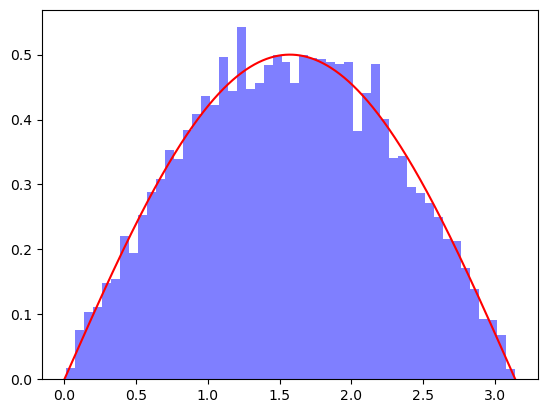

In [1]:
import torch
import torch.nn as nn
try:
    import torchviz
    is_torchviz = True
except ImportError:
    print("torchviz is not installed. Please install it using 'pip install torchviz' to visualize the computation graph.")
    is_torchviz = False
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def sample_from_distribution(model, n_samples=1000, device=device, box = [0,torch.pi]):
    
    x = torch.rand(n_samples, 1, device=device) * (box[1] - box[0]) + box[0]
    model_old = model(x)
    with torch.no_grad():
        for _ in range(n_samples):
            x_new = x + torch.randn_like(x) * 0.1  # Small perturbation
            model_new = model(x_new)
            acceptance_ratio = ((model_new) / (model_old)).clamp(max=1.0)
            accept = torch.rand_like(acceptance_ratio) < acceptance_ratio
            x = torch.where(accept, x_new, x)
            model_old = model(x)
    return x

class sin(nn.Module):
    def __init__(self):
        super(sin, self).__init__()

    def forward(self, x):
        return torch.sin(x)

model = sin().to(device)

x = sample_from_distribution(model, n_samples=10_000, device=device)

plt.hist(x.cpu().numpy(), bins=50, density=True, alpha=0.5, color='blue')

analytic_model = model(torch.linspace(0, torch.pi, 1000).to(device))
norm = (torch.trapz(analytic_model, torch.linspace(0, torch.pi, 1000).to(device)))
analytic_model = analytic_model / norm

plt.plot(torch.linspace(0, torch.pi, 1000).cpu().numpy(), analytic_model.cpu().numpy(), color='red')

# Test MCMC with default torch randn

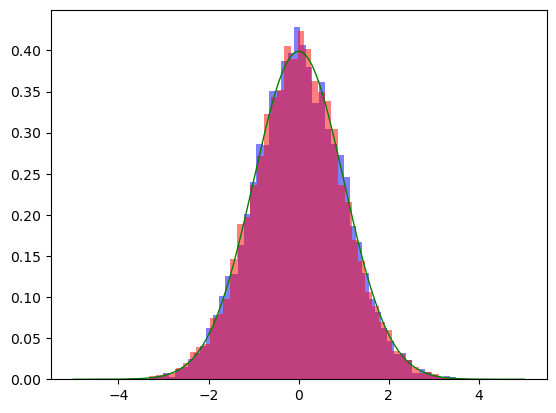

In [2]:
samples = 10_000
sampled_gauss = torch.randn(samples, 1, device=device)
class GaussianModel(nn.Module):
    def forward(self, x):
        return torch.exp(-0.5 * x**2)
plt.hist(sampled_gauss.cpu().numpy(), bins=50, density=True, alpha=0.5, color='blue')
gaussian_model = GaussianModel()
sampled_gauss_mc = sample_from_distribution(gaussian_model, n_samples=samples, device=device, box=[-5, 5])
plt.hist(sampled_gauss_mc.cpu().numpy(), bins=50, density=True, alpha=0.5, color='red', label='Sampled Gaussian')
def gaussian(x):
    return torch.exp(-0.5 * x**2) / torch.sqrt(torch.tensor(2 * torch.pi))
plt.plot(torch.linspace(-5, 5, 1000).cpu().numpy(), gaussian(torch.linspace(-5, 5, 1000).to(device)).cpu().numpy(), color='green', label='Analytic Gaussian', linewidth=1)

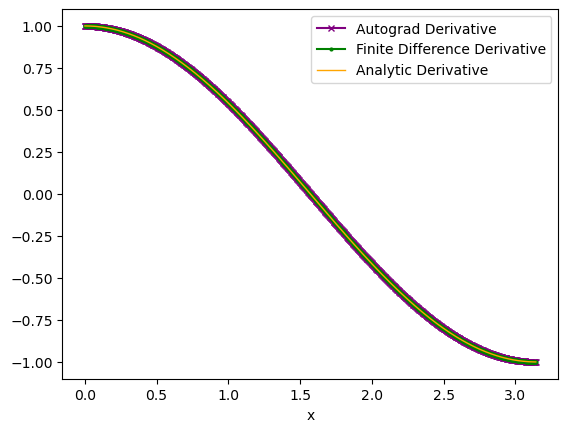

In [3]:
def finite_difference_derivative(model, x):
    # if isinstance(model,(nn.Module, callable)):
    #     y = model(x)
    # else:
    #     y = model
    y = model(x)
    dy_dx = torch.zeros_like(y)
    h = x[2] - x[1]  # Use the spacing between points as step size
    dy_dx[1:-1] = (y[2:]-y[0:-2]) / (2 * h)  # Central difference for interior points
    dy_dx[0] = (y[1] - y[0]) / h  # Forward difference for the first point
    dy_dx[-1] = (y[-1] - y[-2]) / h

    return dy_dx

def compute_autograd_derivative(model, x):
    x.requires_grad = True
    # if isinstance(model,nn.Module):
    #     y = model(x)
    # else:
    #     y = model
    y = model(x)
    dy_dx = torch.autograd.grad(y, x, create_graph=True, grad_outputs=torch.ones_like(y))[0]
    return dy_dx

autograd_dsin = compute_autograd_derivative(model, torch.linspace(0, torch.pi, 1000).to(device))
plt.plot(torch.linspace(0, torch.pi, 1000).cpu().numpy(), autograd_dsin.cpu().detach().numpy(), color='purple', label='Autograd Derivative', marker='x', markersize=4)

dsin = finite_difference_derivative(model, torch.linspace(0, torch.pi, 1000).to(device))
plt.plot(torch.linspace(0,torch.pi,1000), dsin.cpu().numpy(), color='green', label='Finite Difference Derivative', marker='o', markersize=2)
plt.plot(torch.linspace(0, torch.pi, 1000).cpu().numpy(), torch.cos(torch.linspace(0, torch.pi, 1000)).cpu().numpy(), color='orange', label='Analytic Derivative', linewidth=1)
plt.xlabel('x')
plt.legend()

In [4]:
def integral(model, x):
    if isinstance(model, nn.Module):
        y = model(x)
    else:
        y = model
    integral_value = torch.trapz(y, x)
    return integral_value

def mc_integral(model, n_samples=1000, device=device):
    x_samples = torch.rand(n_samples, 1, device=device) * (torch.pi - 0) + 0
    y_samples = model(x_samples)
    integral_value = torch.mean(y_samples) * (torch.pi - 0)
    return integral_value

L = 2

x = torch.linspace(0, torch.pi, 1000).to(device)
integral_value = integral(model, x)
mc_integral_value = mc_integral(model, n_samples=5000, device=device)
print(f"Integral value (Trapezoid): {integral_value.item()}")
print(f"Integral value (MC): {mc_integral_value.item()}")

Integral value (Trapezoid): 1.9999984502792358
Integral value (MC): 1.9836710691452026


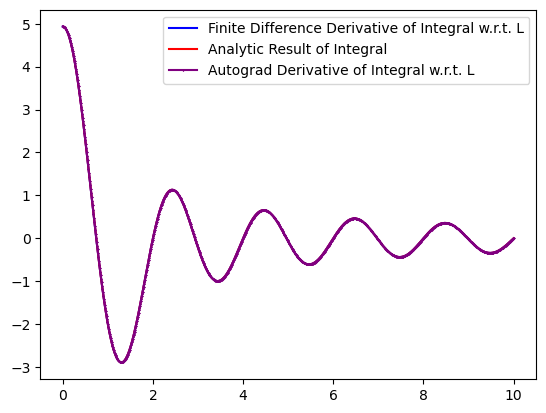

In [5]:
class sin_lx(nn.Module):
    def __init__(self, L=2):
        super(sin_lx, self).__init__()
        self.L = L

    def forward(self, x):
        return torch.sin(self.L * x)
    
def der_integral(L):
    x = torch.linspace(0, torch.pi, 1000).to(device)
    result = torch.zeros_like(x)
    for i in range(len(L)):
        l = L[i]
        # COMPUTED WITH WOLFRAM ALPHA
        # https://www.wolframalpha.com/input?i=derivative+with+respect+to+L+of+integral+of+sin%28x*L%29+from+0+to+pi
        result[i] = (torch.pi*l*torch.sin(torch.pi*l)+torch.cos(torch.pi*l)-1)/(l**2)
    return result

def f(L):
    integral_result = torch.zeros_like(L)
    for i in range(len(L)):
        sin_lx_model = sin_lx(L[i]).to(device)
        x = torch.linspace(0, torch.pi, 1000).to(device)
        integral_value = integral(sin_lx_model, x)
        integral_result[i] = integral_value
    return integral_result

L_values = torch.linspace(0.0, 10, 1000).to(device)
df_dl = finite_difference_derivative(f, L_values)
y = f(L_values)
y.requires_grad = True
autograd_df_dl = compute_autograd_derivative(f, L_values)
plt.plot(L_values.detach().cpu().numpy(), df_dl.detach().cpu().numpy(), label='Finite Difference Derivative of Integral w.r.t. L', color='blue')
plt.plot(L_values.detach().cpu().numpy(), der_integral(L_values).detach().cpu().numpy(), label='Analytic Result of Integral', color='red')
plt.plot(L_values.detach().cpu().numpy(), autograd_df_dl.detach().cpu().numpy(), label='Autograd Derivative of Integral w.r.t. L', color='purple', marker='x', markersize=1)

plt.legend()

$$f(\lambda) = \int_0^\pi \sin(x\lambda)dx$$

In [6]:
class T_int_sin_lx_dx(nn.Module):
    def __init__(self, L=2):
        super(T_int_sin_lx_dx, self).__init__()

    def forward(self, L):
        x = torch.linspace(0, torch.pi, 1000).to(device)
        result = torch.zeros_like(x)
        for i in range(len(L)):
            L_i = L[i]
            result[i] = torch.trapz(torch.sin(L_i * x), x)
        return result
    
class MC_int_sin_lx_dx(nn.Module):
    def __init__(self, L=2, n_samples=100_000, device=device):
        super(MC_int_sin_lx_dx, self).__init__()
        self.L = L
        self.n_samples = n_samples
        self.device = device

    def forward(self, L):
        
        result = torch.zeros_like(L)
        for i in range(len(L)):
            L_i = L[i]
            x_samples = torch.rand(self.n_samples, 1, device=self.device) * (torch.pi - 0) + 0
            y_samples = torch.sin(L_i * x_samples)
            integral_value = torch.mean(y_samples) * (torch.pi - 0)
            result[i] = integral_value
        return result


def analytic_result(L):
    """
    Computes the analytic result of the integral of sin(L*x) from 0 to pi
    with respect to L.
    """
    result = torch.zeros_like(L)
    for i in range(len(L)):
        # COMPUTED WITH WOLFRAM ALPHA
        L_i = L[i]
        result[i] = (1-torch.cos(torch.pi * L_i) )/L_i
    return result

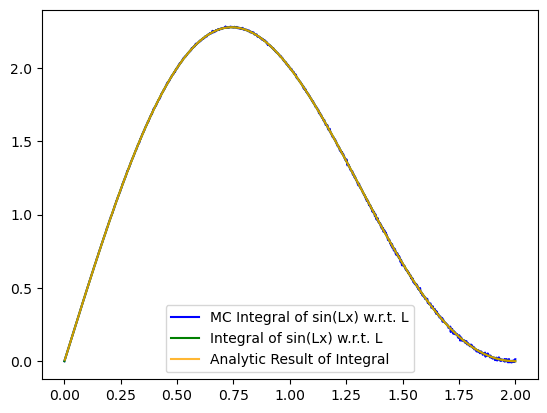

In [7]:
L_vals = torch.linspace(0.0, 2, 1000).to(device)
model = T_int_sin_lx_dx().to(device)
mc_model = MC_int_sin_lx_dx().to(device)
mc_y = mc_model(L_vals)
plt.plot(L_vals.cpu().numpy(), mc_y.cpu().numpy(), label='MC Integral of sin(Lx) w.r.t. L', color='blue', markersize=1)
y = model(L_vals)
plt.plot(L_vals.cpu().numpy(), y.cpu().numpy(), label='Integral of sin(Lx) w.r.t. L', color='green', markersize=1)
plt.plot(L_vals.cpu().numpy(), analytic_result(L_vals).cpu().numpy(), label='Analytic Result of Integral', color='orange', alpha=0.8)

plt.legend()

# COMPUTING THE GRADIENTS WITH A SINGLE PARAMETER WITH MCMC INTEGRATION

$$\mathcal{L}_\lambda = \int p(x) f(x,\lambda)dx$$

$$\mathcal{L}_\lambda=\frac{1}{\sqrt{2\pi}}\int_{-\infty}^{\infty}e^{-\frac12 x^2+\lambda x} = \frac{1}{\sqrt{2\pi}}e^{\frac{\lambda^2}{4\cdot{\frac{1}{2}}}}\sqrt{\frac{\pi}{\frac{1}{2}}} = e^{\frac{\lambda^2}{2}}$$

- MCMC
  $$\mathcal{L}_\lambda=\frac{1}{\sqrt{2\pi}}\int_{-\infty}^{\infty}e^{-\frac12 x^2+\lambda x} = \frac{1}{\sqrt{2\pi}}\int_{-\infty}^{\infty}e^{-\frac12 x^2}e^{\lambda x}$$

  $$p(x) = \frac{1}{\sqrt{2\pi}}e^{-\frac{1}{2}x^2}\to \int_{-\infty}^{\infty}\frac{e^{-\frac12 x^2}}{\sqrt{2\pi}}e^{\lambda x}\to \int_{-\infty}^{\infty}p(x) e^{\lambda x}$$
  
  $$\mathcal{L}_\lambda = \int_{-\infty}^{\infty}p(x) e^{\lambda x} \approx \frac{1}{N}\sum_{i(x_i\sim \mathcal{N}(0,1))} e^{\lambda x_i}$$

Loss: 1.136247158050537 Std: 0.6005581021308899 Manual Std: 0.597647488117218
Loss BM: 1.1347219944000244
Loss Copy: 1.1347219944000244
Loss Trapezoidal: 1.133148431777954
analytic: 1.133148431777954


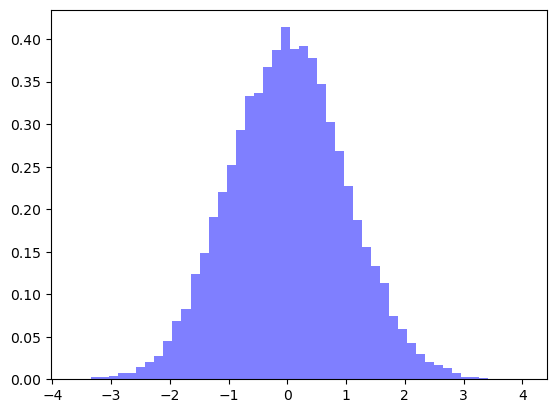

In [8]:
# PARAMETERS TO PLAY WITH
N_SAMPLES = 15_000
L_value = 0.5
# -----------------------

# DEFINE INTEGRAL 
class Integrand(nn.Module):
    def __init__(self, L=1.0):
        super(Integrand, self).__init__()
        # When defining the parameter, we use requires_grad=True to allow optimization
        self.L = torch.nn.Parameter(L, requires_grad=True)

    def forward(self, x):
        return torch.exp(self.L * x)
    
class FullIntegrand(nn.Module):
    def __init__(self, L=1.0):
        super(FullIntegrand, self).__init__()
        self.L = torch.nn.Parameter(torch.tensor(L, dtype=torch.float32), requires_grad=True)

    def forward(self, x):
        return (1/torch.sqrt(torch.tensor(2*torch.pi)))*torch.exp(-0.5*x.pow(2)+self.L * x)
    
class Gaussian(nn.Module):
    def __init__(self,mu = 0.0, sigma=1.0):
        super(Gaussian, self).__init__()
        self.sigma = torch.nn.Parameter(torch.tensor(sigma, dtype=torch.float32), requires_grad=True)
        self.mu = torch.nn.Parameter(torch.tensor(mu, dtype=torch.float32), requires_grad=True)
    def forward(self, x):
        return (1/(self.sigma * torch.sqrt(torch.tensor(2 * torch.pi)))) * torch.exp(-0.5 * ((x - self.mu) / self.sigma).pow(2))
# -----------------------

x = torch.randn(N_SAMPLES, 1, device=device) # Use a normal distribution
import copy
x_copy = copy.deepcopy(x)  # Create a copy of x to avoid modifying the original tensor
gaussian_model = Gaussian()
x_own = sample_from_distribution(gaussian_model, n_samples=N_SAMPLES)
x_own.requires_grad = True
plt.hist(x_own.detach().cpu().numpy(), bins=50, density=True, alpha=0.5, color='blue', label='Sampled Gaussian')
L = torch.tensor([L_value], device=device)
x_linspace = torch.linspace((L_value-6), (L_value+6), N_SAMPLES, device=device).view(-1, 1)  # Use a range for x
model = Integrand(L=L).to(device)
model2 = Integrand(L=L).to(device)  # Using the same L value for the second model
model3 = Integrand(L=L).to(device)  # Using the same L value for the third model
model_trapz = FullIntegrand(L=L_value).to(device)  # Using the full integrand for trapezoidal rule
y = model_trapz(x_linspace)  # Using the full integrand for trapezoidal rule

loss = torch.mean(model(x_own)) # compute the integral
loss_BM = torch.mean(model2(x)) # compute the integral
loss_copy = torch.mean(model3(x_copy))  # compute the integral on the copied tensor
loss_trapz = torch.trapezoid(y, x_linspace, dim=0)  # Compute the integral using trapezoidal rule

manual_std = (torch.mean(model(x)**2) - loss**2).sqrt()  # Manual standard deviation calculation

std = torch.std(model(x))

print("Loss:", loss.item(), "Std:", std.item(), "Manual Std:", manual_std.item())
print("Loss BM:", loss_BM.item())
print("Loss Copy:", loss_copy.item())
print("Loss Trapezoidal:", loss_trapz.item())
print("analytic:", torch.exp(L**2 / 2).item())

# plt.plot(x.cpu().numpy(), model(x).cpu().detach().numpy(), '.', markersize=1, label='Model Output')

# Gradient wrt $\lambda$

- Analytic
$$\partial_\lambda \mathcal{L_\lambda} = \partial_\lambda e^{\frac{\lambda^2}{2}} = \lambda e^{\frac{\lambda^2}{2}}$$

In [9]:
for name, param in model.named_parameters():
    print(f"Parameter: {name}\n", param[0])
try: # Pytorch will throw an error if the gradients are computed twice
    loss.backward() # COMPUTES GRADIENTS!
    loss_trapz.backward()  # Compute gradients for trapezoidal loss
    loss_BM.backward()  # Compute gradients for the baseline model
    loss_copy.backward()  # Compute gradients for the copied tensor
except RuntimeError as e:
    pass

# grad_L_model = model.L.grad.item()
# grad_L_trapz = model_trapz.L.grad.item()

print("Gradient of L (requires_grad: True):", model.L.grad.item())
print("Gradient of L (copy):", model3.L.grad.item())
print("Gradient of L (BM)):", model2.L.grad.item())
print("Gradient of L (trapz):", model_trapz.L.grad.item())
print("analytic gradient:", (torch.exp(L**2 / 2) * L).item())

Parameter: L
 tensor(0.5000, device='cuda:0', grad_fn=<SelectBackward0>)
Gradient of L (requires_grad: True): 0.5720466375350952
Gradient of L (copy): 0.56963050365448
Gradient of L (BM)): 0.56963050365448
Gradient of L (trapz): 0.5665742754936218
analytic gradient: 0.566574215888977


In [10]:
def print_graph(g, indent=0):
    if g is None:
        return
    print("  " * indent + str(g))
    if hasattr(g, 'next_functions'):
        for nf in g.next_functions:
            if nf[0] is not None:
                print_graph(nf[0], indent + 1)

if is_torchviz:
    # Visualize the computation graph
    dot = torchviz.make_dot(loss, params=dict(model.named_parameters()))
    dot.render("computation_graph", format="png")  # Save the graph as a PNG
    dot_trapz = torchviz.make_dot(loss_trapz, params=dict(model_trapz.named_parameters()))
    dot_trapz.render("computation_graph_trapz", format="png")  #
    dot_BM = torchviz.make_dot(loss_BM, params=dict(model.named_parameters()))
    dot_BM.render("computation_graph_BM", format="png")  # Save
else:
    print("BM graph\n")
    print_graph(loss_BM.grad_fn)
    print(".......................\nTrapezoidal graph\n")
    print_graph(loss_trapz.grad_fn)
    print(".......................\nModel graph\n")
    print_graph(loss.grad_fn)


In [11]:
attr_own = dir(x_own)
attr_dict = dir(x)
# print all attributes of x_own
print("Attributes of x_own:")
for attr in dir(x_own):
    if not attr.startswith('__'):
        try:
            print(f"{attr}: {getattr(x_own, attr)}")
        except RuntimeError as e:
            print(f"{attr}: {e}")
print("------------------------\n")
print("\nAttributes of x:")
for attr in dir(x):
    if not attr.startswith('__'):
        try:
            print(f"{attr}: {getattr(x_own, attr)}")
        except RuntimeError as e:
            print(f"{attr}: {e}")


Attributes of x_own:
H: tensor([[-0.1824, -0.3853,  1.6012,  ..., -2.0852, -0.3765, -0.0969]],
       device='cuda:0', grad_fn=<TransposeBackward0>)
T: tensor([[-0.1824, -0.3853,  1.6012,  ..., -2.0852, -0.3765, -0.0969]],
       device='cuda:0', grad_fn=<PermuteBackward0>)
_addmm_activation: <built-in method _addmm_activation of Tensor object at 0x7421dafdb750>
_autocast_to_full_precision: <built-in method _autocast_to_full_precision of Tensor object at 0x7421dafdb750>
_autocast_to_reduced_precision: <built-in method _autocast_to_reduced_precision of Tensor object at 0x7421dafdb750>
_backward_hooks: None
_base: None
_cdata: 979693536
_clear_non_serializable_cached_data: <bound method Tensor._clear_non_serializable_cached_data of tensor([[-0.1824],
        [-0.3853],
        [ 1.6012],
        ...,
        [-2.0852],
        [-0.3765],
        [-0.0969]], device='cuda:0', requires_grad=True)>
_coalesced_: <built-in method _coalesced_ of Tensor object at 0x7421dafdb750>
_conj: <built-in

In [12]:
# compare attributes of x_own and x
print("\nAttributes of x_own that are not in x:")

for attr in attr_own:
    if attr not in attr:
        try:
            print(f"{attr}: {getattr(x_own, attr)}")
        except RuntimeError as e:
            print(f"{attr}: {e}")

print("\nAttributes of x that are not in x_own:")

for attr in attr_dict:
    if attr not in attr_own:
        try:
            print(f"{attr}: {getattr(x, attr)}")
        except RuntimeError as e:
            print(f"{attr}: {e}")

x_own.requires_grad, x.requires_grad


Attributes of x_own that are not in x:

Attributes of x that are not in x_own:


(True, False)

# Test the whole software with a stupid function

$V(x) = \frac12 x^2$:

$$\phi_\alpha(x) = e^{-\alpha x^2}$$

$$E_{loc}^\alpha = -\frac{1}{2}2\alpha(2\alpha x^2-1) + \frac12 x^2 = \dots = \alpha - x ^2\bigg(\frac12-2\alpha\bigg)$$

In [13]:
import sys
import os

# Compute absolute path to the src/ folder
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
src_path = os.path.join(project_root, "src")

# Add src/ to sys.path
sys.path.insert(0, src_path)

# Now you can import the code
from qvarnet.hamiltonians import HarmonicOscillator
from qvarnet.samplersv2 import MetropolisHastingsSampler


import torch
import torch.nn as nn
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Parameter a:
 0.10000000149011612
parameters: OrderedDict({'a': tensor(0.1000, device='cuda:0')})
parameters: OrderedDict({'a': tensor(0.1000, device='cuda:0')})
parameters: OrderedDict({'a': tensor(0.1000, device='cuda:0')})
parameters: OrderedDict({'a': tensor(0.1000, device='cuda:0')})
parameters: OrderedDict({'a': tensor(0.1000, device='cuda:0')})
parameters: OrderedDict({'a': tensor(0.1000, device='cuda:0')})
parameters: OrderedDict({'a': tensor(0.1000, device='cuda:0')})
parameters: OrderedDict({'a': tensor(0.1000, device='cuda:0')})
parameters: OrderedDict({'a': tensor(0.1000, device='cuda:0')})
parameters: OrderedDict({'a': tensor(0.1000, device='cuda:0')})
parameters: OrderedDict({'a': tensor(0.1000, device='cuda:0')})
parameters: OrderedDict({'a': tensor(0.1000, device='cuda:0')})
parameters: OrderedDict({'a': tensor(0.1000, device='cuda:0')})
parameters: OrderedDict({'a': tensor(0.1000, device='cuda:0')})
parameters: OrderedDict({'a': tensor(0.1001, device='cuda:0')})
parame

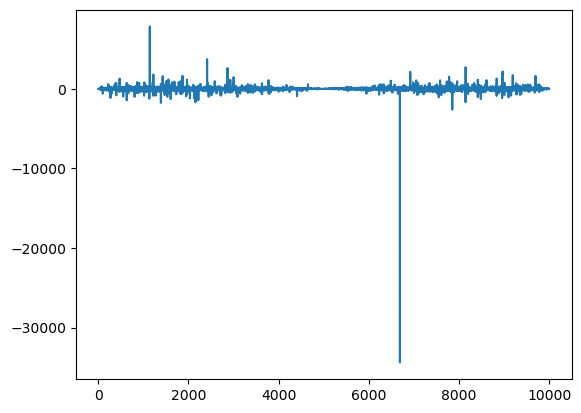

 energy: nan
Ended training.


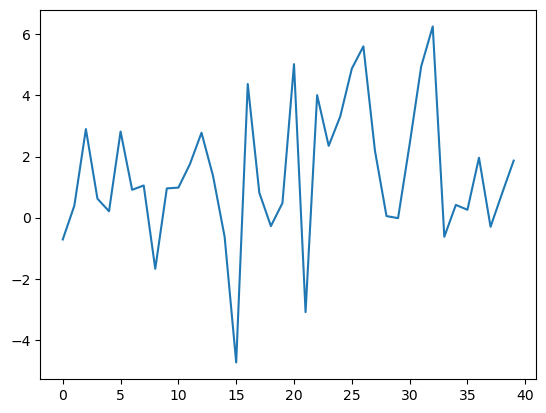

In [30]:
import time
from tqdm import tqdm
from torchviz import make_dot
import numpy as np


#----------------------- DEFINE PARAMETERS -----------------------
EPOCHS             = 1_00
N_SAMPLES          = 10_000
L_BOX              = 20.0
STEP_SIZE          = 0.1
BURN_IN            = 500
CALLBACK_PATIENCE  = 10000
CALLBACK_MIN_DELTA = 1e-5
LEARNING_RATE      = 1e-5
MLP_LAYER_DIMS     = [1, 10, 1]
DEBUG              = False

wf_history      = []
samples_history = []
energy_history  = []

local_energy_history = []
samples_history = []
dict_state_history = []

#----------------------- DEFINE MODEL TOPOLOGY -----------------------
class StupidAnsatz(nn.Module):
    def __init__(self, a):
        super(StupidAnsatz, self).__init__()
        self.a = torch.nn.Parameter(torch.tensor(a, dtype=torch.float32), requires_grad=True)

    def forward(self, x):
        return torch.exp(-self.a * x**2)
model = StupidAnsatz(a=0.1)  # Initialize with a small value for a
model.to(device)


#------------------------ DEFINE HAMILTONIAN -----------------------
hamiltonian = HarmonicOscillator(model=model)
hamiltonian.to(device)

#------------------------ DEFINE SAMPLER -----------------------
sampler = MetropolisHastingsSampler(
    model     = model,
    n_samples = N_SAMPLES,
    step_size = STEP_SIZE,
    burn_in   = BURN_IN,
    is_wf     = True,
    L_BOX     = L_BOX,
)
sampler.to(device)

# callback = EarlyStoppingCallback(patience=CALLBACK_PATIENCE, min_delta=CALLBACK_MIN_DELTA)
callback = None  # Disable early stopping for now

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

for name, param in model.named_parameters():
    if param is not None:
        print(f"Parameter {name}:\n {param.data.cpu().numpy() if param is not None else None}")

sampling_times = []
energy_times = []

x_trapezoid = torch.linspace(-L_BOX/2, L_BOX/2, 10_000).view(-1, 1).to(device)
x_trapezoid.requires_grad = True  # Ensure x_trapezoid is differentiable

for epoch in (range(EPOCHS)):
    optimizer.zero_grad()
    
    # x0 = torch.randn(1, device=device)
    start_sample_time = time.time()
    # Run sampler
    sampler.model = model
    x0 = torch.tensor([0.0], device=device)  # Initial point for the sampler
    samples = sampler(x0, method="parallel", n_walkers=(N_SAMPLES)).requires_grad_(False)
    # samples.requires_grad = True
    end_sample_time = time.time()
    sampling_times.append(end_sample_time - start_sample_time)
    samples_history.append(samples.cpu().detach())
    dict_state_history.append(model.state_dict())
    
    # Compute the mean and std of the local energy
    start_energy_time = time.time()
    hamiltonian.model = model
    local_energy = hamiltonian(samples)
    squared_psi = model(samples).pow(2)
    sampled_norm = torch.mean(squared_psi)
    local_energy_history.append(local_energy.cpu().detach())
    
    psi_values = model(samples)
    psi_std = psi_values.std()
    
    end_energy_time = time.time()
    energy_times.append(end_energy_time - start_energy_time)

    loss = local_energy.mean()
    
    wf_history.append(model.state_dict())
    samples_history.append(samples)
    energy_history.append(loss.item())
    # Compute gradients
    loss.squeeze().backward()
    
    optimizer.step()
    print(f"parameters: {model.state_dict()}")
    if np.any(np.isnan(model.state_dict()['a'].cpu().detach().numpy())):
        print("NaN detected in model parameters, stopping training.")
        plt.plot(local_energy.cpu().detach().numpy(), label='Local Energy')
        plt.show()
        print(f" energy: {loss.item()}")
        break

    sampler.reset_statistics()

print("Ended training.")
plt.plot(energy_history, label='Energy History')

10000
Local energy tensor([-34379.8594], device='cuda:0', grad_fn=<UnbindBackward0>) at index 6689 is less than -10000, stopping.
samples at index 6689: tensor([2.8671], device='cuda:0')
dict_state_history: [OrderedDict({'a': tensor(nan, device='cuda:0')}), OrderedDict({'a': tensor(nan, device='cuda:0')}), OrderedDict({'a': tensor(nan, device='cuda:0')}), OrderedDict({'a': tensor(nan, device='cuda:0')}), OrderedDict({'a': tensor(nan, device='cuda:0')}), OrderedDict({'a': tensor(nan, device='cuda:0')}), OrderedDict({'a': tensor(nan, device='cuda:0')}), OrderedDict({'a': tensor(nan, device='cuda:0')}), OrderedDict({'a': tensor(nan, device='cuda:0')}), OrderedDict({'a': tensor(nan, device='cuda:0')}), OrderedDict({'a': tensor(nan, device='cuda:0')}), OrderedDict({'a': tensor(nan, device='cuda:0')}), OrderedDict({'a': tensor(nan, device='cuda:0')}), OrderedDict({'a': tensor(nan, device='cuda:0')}), OrderedDict({'a': tensor(nan, device='cuda:0')}), OrderedDict({'a': tensor(nan, device='cuda

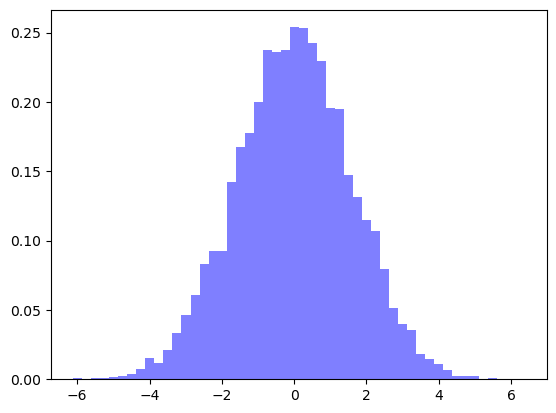

In [44]:
plt.hist(samples.cpu().detach().numpy(), bins=50, density=True, alpha=0.5, color='blue', label='Sampled Distribution');
print(len(samples.cpu().detach().numpy()))
for i,loc_en in enumerate(local_energy):
    if loc_en < -10000:
        print(f"Local energy {loc_en} at index {i} is less than -10000, stopping.")
        print(f"samples at index {i}: {samples[i]}")
        model.load_state_dict(dict_state_history[-3])
        print(f"dict_state_history: {dict_state_history}")
        for name, param in model.named_parameters():
            print(f"Parameter {name}:\n {param.data.cpu().numpy() if param is not None else None}")
        print(f"Total energy: {torch.mean(model(samples))}")

In [18]:
print("Final model parameters:")
for name, param in model.named_parameters():
    if param is not None:
        print(f"Parameter {name}:\n {param.data.cpu().numpy() if param is not None else None}")

Final model parameters:
Parameter a:
 0.10000402480363846
